# 逻辑回归

在本次练习中，你将实现逻辑回归并将其应用于两个不同的数据集。

# 大纲 
- [1 - 包](#1)
- [2 - 逻辑回归](#2)
  - [2.1 问题陈述](#2.1)
  - [2.2 加载并可视化数据](#2.2)
  - [2.3  sigmoid 函数](#2.3)
  - [2.4 逻辑回归的代价函数](#2.4)
  - [2.5 逻辑回归的梯度](#2.5)
  - [2.6 使用梯度下降学习参数](#2.6)
  - [2.7 绘制决策边界](#2.7)
  - [2.8 评估逻辑回归](#2.8)
- [3 - 正则化逻辑回归](#3)
  - [3.1 问题陈述](#3.1)
  - [3.2 加载并可视化数据](#3.2)
  - [3.3 特征映射](#3.3)
  - [3.4 正则化逻辑回归的代价函数](#3.4)
  - [3.5 正则化逻辑回归的梯度](#3.5)
  - [3.6 使用梯度下降学习参数](#3.6)
  - [3.7 绘制决策边界](#3.7)
  - [3.8 评估正则化逻辑回归模型](#3.8)


<a name="1"></a>
## 1 - 软件包
首先，让我们运行下面的单元格以导入在本次作业中你将需要的所有软件包。
- [numpy](www.numpy.org)是使用 Python 进行科学计算的基础软件包。
- [matplotlib](http://matplotlib.org)是一个著名的用于在 Python 中绘制图形的库。-“utils.py”包含本次作业的辅助函数。你不需要修改此文件中的代码。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math

%matplotlib widget

<a name="2"></a>
## 2 - 逻辑回归
在本部分练习中，你将构建一个逻辑回归模型来预测学生是否被大学录取。

<a name="2.1"></a>
### 2.1 问题陈述
假设你是一所大学院系的管理员，你想根据申请人在两门考试中的成绩来确定每个申请人被录取的机会。
* 你有来自以前申请人的历史数据，可以将其用作逻辑回归的训练集。
* 对于每个训练示例，你有申请人在两门考试中的分数以及录取决定。
* 你的任务是构建一个分类模型，根据这两门考试的分数来估计申请人被录取的概率。 

<a name="2.2"></a>
### 2.2 加载并可视化数据
你将从加载此任务的数据集开始。
- 如下所示的`load_dataset()`函数将数据加载到变量`X_train`和`y_train`中。
  - `X_train`包含学生两门考试的分数。
  - `y_train`是录取决定。
      - 如果学生被录取，`y_train = 1`。
      - 如果学生未被录取，`y_train = 0`。
  - `X_train`和`y_train`都是 numpy 数组。


In [2]:
# load dataset
X_train, y_train = load_data("data/ex2data1.txt")

#### 查看变量
让我们更加熟悉你的数据集。 
- 一个好的开始是打印出每个变量并查看它包含的内容。

下面的代码打印出`X_train`的前五个值以及该变量的类型。

In [3]:
print("First five elements in X_train are:\n", X_train[:5])
print("Type of X_train:",type(X_train))

First five elements in X_train are:
 [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
Type of X_train: <class 'numpy.ndarray'>


现在打印`y_train`的前五个值。

In [4]:
print("First five elements in y_train are:\n", y_train[:5])
print("Type of y_train:",type(y_train))

First five elements in y_train are:
 [0. 0. 0. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


#### 检查变量的维度
另一种熟悉数据的有用方法是查看其维度。让我们打印`X_train`和`y_train`的形状，看看我们的数据集中有多少个训练样本。

In [5]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


#### 可视化你的数据

在开始实现任何学习算法之前，如果可能的话，总是先将数据可视化比较好。
- 下面的代码在二维图上显示数据（如下图所示），其中坐标轴是两次考试的分数，正例和负例用不同的标记显示。
- 我们使用“utils.py”文件中的一个辅助函数来生成此图。

<img src="images/figure 1.png" width="450" height="450">



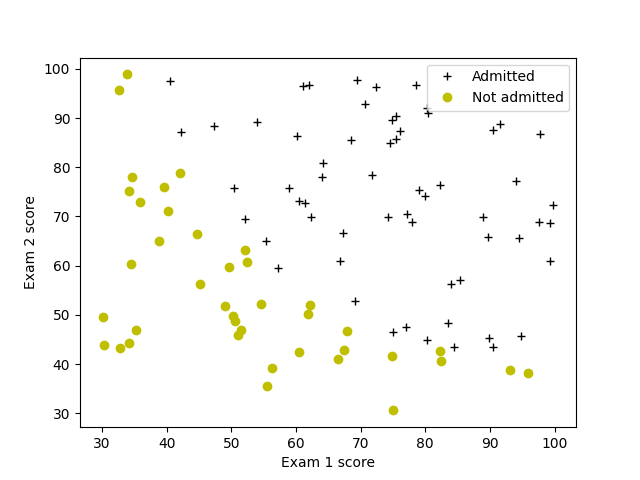

In [6]:
# Plot examples
plt.clf()
plot_data(X_train, y_train[:], pos_label="Admitted", neg_label="Not admitted")

# Set the y-axis label
plt.ylabel('Exam 2 score') 
# Set the x-axis label
plt.xlabel('Exam 1 score') 
plt.legend(loc="upper right")
plt.show()

你的目标是建立一个逻辑回归模型来拟合这些数据。
- 有了这个模型，你就可以根据新学生在两场考试中的成绩来预测他们是否会被录取。

<a name="2.3"></a>
### 2.3  Sigmoid 函数
回想一下，对于逻辑回归，模型表示为：

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$
其中函数$g$是 Sigmoid 函数。Sigmoid 函数定义为：

$$g(z) = \frac{1}{1+e^{-z}}$$

首先，让我们实现 Sigmoid 函数，以便本作业的其余部分可以使用它。

<a name='ex-01'></a>
### 练习 1
请完成`sigmoid`函数的计算。

$$g(z) = \frac{1}{1+e^{-z}}$$

请注意
- `z`并不总是一个单一的数字，也可以是一个数字数组。
- 如果输入是一个数字数组，我们希望将 Sigmoid 函数应用于输入数组中的每个值。

如果你遇到困难，可以查看下面单元格后的提示来帮助你实现。

In [7]:
# UNQ_C1
# GRADED FUNCTION: sigmoid

def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z
         
    """
          
    ### START CODE HERE ### 
    g = 1 / (1 + np.exp(-z))
    ### END SOLUTION ###  
    
    return g

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
       
`numpy`有一个名为[`np.exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html)的函数，它提供了一种方便的方法来计算输入数组（`z`）中所有元素的指数（$e^{z}$）。
 
<details>
          <summary><font size="2" color="darkblue"><b>点击获取更多提示</b></font></summary>
        
- 你可以将$e^{-z}$翻译成代码为`np.exp(-z)`。

- 你可以将$1/e^{-z}$翻译成代码为`1/np.exp(-z)`。
    
    如果你仍然困惑，可以查看下面给出的提示，以弄清楚如何计算`g`。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 g 的提示</b></font></summary>
        <code>g = 1 / (1 + np.exp(-z))</code>
    </details>


</details>

当你完成后，尝试在下面的单元格中调用`sigmoid(x)`来测试一些值。
- 对于较大的正数 x，sigmoid 函数的值应接近 1；而对于较大的负数，sigmoid 函数的值应接近 0。
- 计算`sigmoid(0)`应该恰好得到 0.5。


In [8]:
print ("sigmoid(0) = " + str(sigmoid(0)))

sigmoid(0) = 0.5


**预期输出**:
<table>
  <tr>
    <td> <b>sigmoid(0)<b></td>
    <td> 0.5 </td> 
  </tr>
</table>
    
- 如前所述，你的代码也应该适用于向量和矩阵。对于矩阵，你的函数应该对每个元素执行 sigmoid 函数。

In [9]:
print ("sigmoid([ -1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

# UNIT TESTS
from public_tests import *
sigmoid_test(sigmoid)

sigmoid([ -1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]
All tests passed!


**预期输出**:
<table>
  <tr>
    <td><b>sigmoid([-1, 0, 1, 2])<b></td> 
    <td>[0.26894142        0.5           0.73105858        0.88079708]</td> 
  </tr>    
  
</table>

<a name="2.4"></a>
### 2.4 逻辑回归的成本函数
在本节中，你将实现逻辑回归的成本函数。

<a name='ex-02'></a>
### 练习 2

请使用以下公式完成compute_cost函数。

回想一下，对于逻辑回归，成本函数的形式为：

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

其中，
* m 是数据集中训练样本的数量。


* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ 是单个数据点的成本：

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ 是模型的预测值, 而 $y^{(i)}$ 是模型的实际标签

*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x^{(i)}} + b)$ 这里函数 $g$ 是 sigmoid 函数.
    * 首先计算一个中间变量可能会有所帮助 $z_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x^{(i)}} + b = w_0x^{(i)}_0 + ... + w_{n-1}x^{(i)}_{n-1} + b$ ，这里 $n$ 是特征个数，在计算前 $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(z_{\mathbf{w},b}(\mathbf{x}^{(i)}))$

注意：
* 在进行此操作时，请记住变量`X_train`和`y_train`不是标量值，而是分别具有形状（$m,n$）和（$m$，1）的矩阵，其中$n$是特征数量，$m$是训练样本的数量。
* 在这部分中，你可以使用上面实现的 sigmoid 型函数。

如果你遇到困难，可以查看下面单元格后面提供的提示来帮助你实现。

In [10]:
# UNQ_C2
# GRADED FUNCTION: compute_cost
def compute_cost(X, y, w, b, lambda_= 1):
    """
    Computes the cost over all examples
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value 
      w : (array_like Shape (n,)) Values of parameters of the model      
      b : scalar Values of bias parameter of the model
      lambda_: unused placeholder
    Returns:
      total_cost: (scalar)         cost 
    """

    m, n = X.shape
    
    ### START CODE HERE ###
    loss_sum = 0 
    
    # Loop over each training example
    for i in range(m): 
        
        # First calculate z_wb = w[0]*X[i][0]+...+w[n-1]*X[i][n-1]+b
        z_wb = 0 
        # Loop over each feature
        for j in range(n): 
            # Add the corresponding term to z_wb
            z_wb_ij = w[j]*X[i][j]
            z_wb += z_wb_ij # equivalent to z_wb = z_wb + z_wb_ij
        # Add the bias term to z_wb
        z_wb += b # equivalent to z_wb = z_wb + b
    
        f_wb = sigmoid(z_wb) # Your code here to calculate prediction f_wb for a training example
        loss = -y[i] * np.log(f_wb) - (1 - y[i]) * np.log(1 - f_wb) # Your code here to calculate loss for a training example
        
        loss_sum += loss # equivalent to loss_sum = loss_sum + loss
    
    total_cost = (1 / m) * loss_sum  
    ### END CODE HERE ### 

    return total_cost

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
   * 你可以将求和运算符（例如：$h=\sum\limits_{i = 0}^{m - 1}2i$）在代码中表示如下：

```python 
    h = 0
    for i in range(m):
        h = h + 2 * i
```
  
   * 在这种情况下，你可以使用 for 循环遍历`X`中的所有示例，并将每次迭代中的`loss`添加到在循环外部初始化的变量（`loss_sum`）中。

   * 然后，你可以将`total_cost`作为`loss_sum`除以`m`返回。
     
<details>
    <summary><font size="2" color="darkblue"><b> Click for more hints</b></font></summary>
        
   * 以下是为该函数构建整体实现的方法。

```python 
def compute_cost(X, y, w, b, lambda_= 1):
    m, n = X.shape

    ### START CODE HERE ###
    loss_sum = 0 
    
    # Loop over each training example
    for i in range(m): 
        
        # First calculate z_wb = w[0]*X[i][0]+...+w[n-1]*X[i][n-1]+b
        z_wb = 0 
        # Loop over each feature
        for j in range(n): 
            # Add the corresponding term to z_wb
            z_wb_ij = # Your code here to calculate w[j] * X[i][j]
            z_wb += z_wb_ij # equivalent to z_wb = z_wb + z_wb_ij
        # Add the bias term to z_wb
        z_wb += b # equivalent to z_wb = z_wb + b
    
        f_wb = # Your code here to calculate prediction f_wb for a training example
        loss =  # Your code here to calculate loss for a training example
        
        loss_sum += loss # equivalent to loss_sum = loss_sum + loss
    
    total_cost = (1 / m) * loss_sum  
    ### END CODE HERE ### 
    
    return total_cost
```
    
如果你仍然困惑，可以查看下面给出的提示，以了解如何计算`z_wb_ij`、`f_wb`和`cost`。
    
<details>
      <summary><font size="2" color="darkblue"><b>计算 z_wb_ij 的提示</b></font></summary>
       &emsp; &emsp; <code> z_wb_ij = w[j]*X[i][j] </code>
</details>
        
<details>
      <summary><font size="2" color="darkblue"><b>计算 f_wb 的提示</b></font></summary>
       &emsp; &emsp; $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(z_{\mathbf{w},b}(\mathbf{x}^{(i)}))$ 其中$g$是 sigmoid 函数。你可以简单地调用上面实现的`sigmoid`函数。
      <details>
          <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f 的更多提示</b></font></summary>
           &emsp; &emsp; 你可以把 f_wb 计算为 <code>f_wb = sigmoid(z_wb) </code>
      </details>
</details>

 <details>
      <summary><font size="2" color="darkblue"><b>计算损失的提示</b></font></summary>
      &emsp; &emsp; 你可以用 <a href="https://numpy.org/doc/stable/reference/generated/numpy.log.html">np.log</a> 函数去计算log
      <details>
          <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算loss的更多提示</b></font></summary>
          &emsp; &emsp; 你可以将损失计算为... <code>loss =  -y[i] * np.log(f_wb) - (1 - y[i]) * np.log(1 - f_wb)</code>
      </details>
</details>
        
</details>

</details>

运行下面的单元格，以使用参数$w$的两种不同初始化方式检查你对`compute_cost`函数的实现。

In [11]:
m, n = X_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

Cost at initial w (zeros): 0.693


**预期输出**:
<table>
  <tr>
    <td> <b>初始 w（零值）处的成本<b></td>
    <td> 0.693 </td> 
  </tr>
</table>

In [12]:
# Compute and display cost with non-zero w
test_w = np.array([0.2, 0.2])
test_b = -24.
cost = compute_cost(X_train, y_train, test_w, test_b)

print('Cost at test w,b: {:.3f}'.format(cost))


# UNIT TESTS
compute_cost_test(compute_cost)


Cost at test w,b: 0.218
All tests passed!


**预期输出**:
<table>
  <tr>
    <td> <b>Cost at test w,b<b></td>
    <td> 0.218 </td> 
  </tr>
</table>

<a name="2.5"></a>
### 2.5 逻辑回归的梯度

在本节中，你将实现逻辑回归的梯度。

回想一下，梯度下降算法是：

$$\begin{align*}& \text{循环直到收敛:} \; \lbrace \newline \; & b := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \newline       \; & w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1}\newline & \rbrace\end{align*}$$

其中，参数 $b$ 和 $w_j$ 都是同时更新的。


<a name='ex-03'></a>
### 练习 3
请完善`compute_gradient`函数，以根据下面的公式（2）和（3）计算$\frac{\partial J(\mathbf{w},b)}{\partial w}$、$\frac{\partial J(\mathbf{w},b)}{\partial b}$。

$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)}) \tag{2}
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)} \tag{3}
$$

* m 是数据集中训练样本的数量。

    
* $f_{\mathbf{w},b}(x^{(i)})$是模型的预测值，而$y^{(i)}$是实际标签。


- **注意**：虽然此梯度看起来与线性回归梯度相同，但实际上公式是不同的，因为线性回归和逻辑回归对$f_{\mathbf{w},b}(x)$有不同的定义。

和之前一样，你可以使用上面实现的 sigmoid 函数，如果你遇到困难，可以查看下面单元格后的提示来帮助你实现。

In [13]:
# UNQ_C3
# GRADED FUNCTION: compute_gradient
def compute_gradient(X, y, w, b, lambda_=None): 
    """
    Computes the gradient for logistic regression 
 
    Args:
      X : (ndarray Shape (m,n)) variable such as house size 
      y : (array_like Shape (m,1)) actual value 
      w : (array_like Shape (n,1)) values of parameters of the model      
      b : (scalar)                 value of parameter of the model 
      lambda_: unused placeholder.
    Returns
      dj_dw: (array_like Shape (n,1)) The gradient of the cost w.r.t. the parameters w. 
      dj_db: (scalar)                The gradient of the cost w.r.t. the parameter b. 
    """
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    ### START CODE HERE ### 
    err  = 0.
    for i in range(m):
        # Calculate f_wb (exactly as you did in the compute_cost function above)
        z_wb = 0
        # Loop over each feature
        for j in range(n): 
           # Add the corresponding term to z_wb
           z_wb_ij = X[i, j] * w[j]
           z_wb += z_wb_ij
        
        # Add bias term 
        z_wb += b
        
        # Calculate the prediction from the model
        f_wb = sigmoid(z_wb)

        # Calculate the  gradient for b from this example
        dj_db_i = f_wb - y[i]

        # add that to dj_db
        dj_db += dj_db_i

        # get dj_dw for each attribute
        for j in range(n):
            # You code here to calculate the gradient from the i-th example for j-th attribute
            dj_dw_ij = (f_wb - y[i])* X[i][j]
            dj_dw[j] += dj_dw_ij

    # divide dj_db and dj_dw by total number of examples
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    ### END CODE HERE ###

        
    return dj_db, dj_dw

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
* 以下是你可以为这个函数构建整体实现的方法。

```python 
def compute_gradient(X, y, w, b, lambda_=None): 
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    ### START CODE HERE ### 
    err  = 0.
    for i in range(m):
        # Calculate f_wb (exactly as you did in the compute_cost function above)
        f_wb = 

        # Calculate the  gradient for b from this example
        dj_db_i = # Your code here to calculate the error

        # add that to dj_db
        dj_db += dj_db_i

        # get dj_dw for each attribute
        for j in range(n):
            # You code here to calculate the gradient from the i-th example for j-th attribute
            dj_dw_ij =  
            dj_dw[j] += dj_dw_ij

    # divide dj_db and dj_dw by total number of examples
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    ### END CODE HERE ###

    return dj_db, dj_dw
```

如果你仍然陷入困境，可以查看下面给出的提示，以了解如何计算`f_wb`、`dj_db_i`和`dj_dw_ij`。
    
<details>
      <summary><font size="2" color="darkblue"><b>计算 f_wb 的提示</b></font></summary>
       &emsp; &emsp; 回想一下，你在上面的<code>compute_cost</code>中计算了<code>f_wb</code> —— 关于如何计算每个中间项的详细提示，请查看该练习下面的提示部分。
<details>
  <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f_wb 的更多提示</b></font></summary>
  &emsp; &emsp; 你可以将 f_wb 计算为
           
```python
for i in range(m):   
   # Calculate f_wb (exactly how you did it in the compute_cost function above)
   z_wb = 0
   # Loop over each feature
   for j in range(n): 
       # Add the corresponding term to z_wb
       z_wb_ij = X[i, j] * w[j]
       z_wb += z_wb_ij

   # Add bias term 
   z_wb += b

   # Calculate the prediction from the model
   f_wb = sigmoid(z_wb)
```
        
</details>
    
</details>

<details>
      <summary><font size="2" color="darkblue"><b>计算 dj_db_i 的提示</b></font></summary>
       &emsp; &emsp; 你可以将 dj_db_i 计算为 <code>dj_db_i = f_wb - y[i]</code>
</details>
        
<details>
      <summary><font size="2" color="darkblue"><b>计算 dj_dw_ij 的提示</b></font></summary>
    &emsp; &emsp; 你可以将 dj_dw_ij 计算为 <code>dj_dw_ij = (f_wb - y[i])* X[i][j]</code>
</details>

</details>

运行下面的单元格，以检查你对带有参数$w$的两种不同初始化的`compute_gradient`函数的实现。

In [14]:
# Compute and display gradient with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw.tolist()}' )

dj_db at initial w (zeros):-0.1
dj_dw at initial w (zeros):[-12.00921658929115, -11.262842205513591]


**预期输出**:
<table>
  <tr>
    <td> <b>dj_db at initial w (zeros)<b></td>
    <td> -0.1 </td> 
  </tr>
  <tr>
    <td> <b>ddj_dw at initial w (zeros):<b></td>
    <td> [-12.00921658929115, -11.262842205513591] </td> 
  </tr>
</table>

In [15]:
# Compute and display cost and gradient with non-zero w
test_w = np.array([ 0.2, -0.5])
test_b = -24
dj_db, dj_dw  = compute_gradient(X_train, y_train, test_w, test_b)

print('dj_db at test_w:', dj_db)
print('dj_dw at test_w:', dj_dw.tolist())

# UNIT TESTS    
compute_gradient_test(compute_gradient)


dj_db at test_w: -0.5999999999991071
dj_dw at test_w: [-44.831353617873795, -44.37384124953978]
All tests passed!


**预期输出**:
<table>
  <tr>
    <td> <b>dj_db at initial w (zeros)<b></td>
    <td> -0.5999999999991071 </td> 
  </tr>
  <tr>
    <td> <b>ddj_dw at initial w (zeros):<b></td>
    <td>  [-44.8313536178737957, -44.37384124953978] </td> 
  </tr>
</table>

<a name="2.6"></a>
### 2.6 使用梯度下降学习参数
与上一个作业类似，现在你将通过使用梯度下降来找到逻辑回归模型的最佳参数。
- 对于这部分内容你不需要实现任何东西。只需运行下面的单元。
- 验证梯度下降是否正确工作的一个好方法是查看$J(\mathbf{w},b)$的值，并检查它是否在每一步都在减小。
- 假设你已经正确实现了梯度并计算了成本，那么$J(\mathbf{w},b)$的值永远不应增加，并且应该在算法结束时收敛到一个稳定的值。

In [16]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X :    (array_like Shape (m, n)
      y :    (array_like Shape (m,))
      w_in : (array_like Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)                 Initial value of parameter of the model
      cost_function:                  function to compute cost
      alpha : (float)                 Learning rate
      num_iters : (int)               number of iterations to run gradient descent
      lambda_ (scalar, float)         regularization constant
      
    Returns:
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(X)
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)   

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

现在让我们运行上面的梯度下降算法来学习我们数据集的参数。

**注意**

下面的代码块需要几分钟才能运行，特别是非向量化版本。你可以减少“迭代次数”以测试你的实现并更快地迭代。如果你有时间，可以尝试运行 100,000 次迭代以获得更好的结果。

In [17]:
np.random.seed(1)
intial_w = 0.01 * (np.random.rand(2).reshape(-1,1) - 0.5)
initial_b = -8


# Some gradient descent settings
iterations = 10000
alpha = 0.001

w,b, J_history,_ = gradient_descent(X_train ,y_train, initial_w, initial_b, 
                                   compute_cost, compute_gradient, alpha, iterations, 0)

Iteration    0: Cost     1.01   
Iteration 1000: Cost     0.31   
Iteration 2000: Cost     0.30   
Iteration 3000: Cost     0.30   
Iteration 4000: Cost     0.30   
Iteration 5000: Cost     0.30   
Iteration 6000: Cost     0.30   
Iteration 7000: Cost     0.30   
Iteration 8000: Cost     0.30   
Iteration 9000: Cost     0.30   
Iteration 9999: Cost     0.30   


<details>
<summary>
    <b>预期输出: Cost     0.30, (Click to see details):</b>
</summary>

    # With the following settings
    np.random.seed(1)
    intial_w = 0.01 * (np.random.rand(2).reshape(-1,1) - 0.5)
    initial_b = -8
    iterations = 10000
    alpha = 0.001
    #

```
Iteration    0: Cost     1.01   
Iteration 1000: Cost     0.31   
Iteration 2000: Cost     0.30   
Iteration 3000: Cost     0.30   
Iteration 4000: Cost     0.30   
Iteration 5000: Cost     0.30   
Iteration 6000: Cost     0.30   
Iteration 7000: Cost     0.30   
Iteration 8000: Cost     0.30   
Iteration 9000: Cost     0.30   
Iteration 9999: Cost     0.30   
```

<a name="2.7"></a>
### 2.7 绘制决策边界
我们现在将使用梯度下降得到的最终参数来绘制线性拟合。如果你正确地实现了前面的部分，你应该会看到以下图像：

<img src="images/figure 2.png"  width="450" height="450">

我们将使用`utils.py`文件中的一个辅助函数来创建此图。

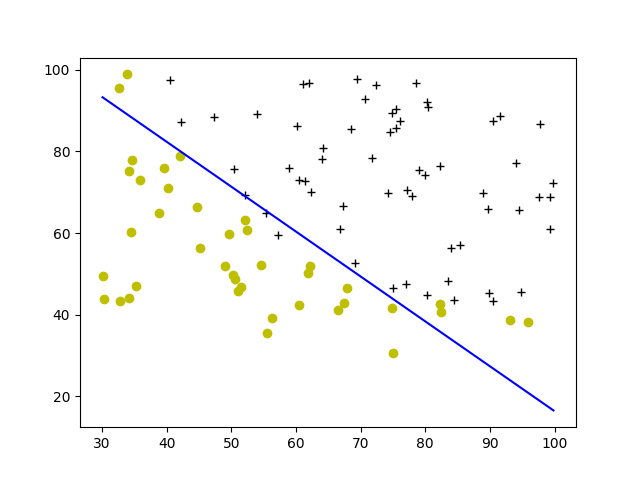

In [18]:
plt.clf()
plot_decision_boundary(w, b, X_train, y_train)
plt.show()

<a name="2.8"></a>
### 2.8 评估逻辑回归
我们可以通过观察所学模型在训练集上的预测效果来评估我们找到的参数的质量。

你将在下面实现`predict`函数来进行此操作。


<a name='ex-04'></a>
### 练习 4

请补全`predict`函数，以便在给定一个数据集以及一个已学习的参数向量$w$和$b$的情况下生成“1”或“0”的预测结果。
- 首先，你需要针对每个示例根据模型$f(x^{(i)}) = g(w \cdot x^{(i)})$计算预测值。
    - 你之前在上面的部分中已经实现过这个。
- 我们将模型的输出（$f(x^{(i)})$）解释为在给定$x^{(i)}$且由$w$参数化的情况下$y^{(i)}=1$的概率。
- 因此，要从逻辑回归模型中得到最终预测结果（$y^{(i)}=0$或$y^{(i)}=1$），你可以使用以下启发式方法：
  
  如果 $f(x^{(i)}) >= 0.5$，预测$y^{(i)}=1$

  如果 $f(x^{(i)}) < 0.5$，预测$y^{(i)}=0$

如果你遇到困难，可以查看下面单元格之后给出的提示来帮助你实现。

In [19]:
# UNQ_C4
# GRADED FUNCTION: predict

def predict(X, w, b): 
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w
    
    Args:
    X : (ndarray Shape (m, n))
    w : (array_like Shape (n,))      Parameters of the model
    b : (scalar, float)              Parameter of the model

    Returns:
    p: (ndarray (m,1))
        The predictions for X using a threshold at 0.5
    """
    # number of training examples
    m, n = X.shape   
    p = np.zeros(m)
   
    ### START CODE HERE ### 
    # Loop over each example
    for i in range(m):   
        # Calculate f_wb (exactly how you did it in the compute_cost function above)
        z_wb = 0
        # Loop over each feature
        for j in range(n): 
           # Add the corresponding term to z_wb
           z_wb_ij = X[i, j] * w[j]
           z_wb += z_wb_ij
        
        # Add bias term 
        z_wb += b
        
        # Calculate the prediction from the model
        f_wb = sigmoid(z_wb)

        # Calculate the prediction for that training example 
        p[i] = f_wb >= 0.5

    ### END CODE HERE ### 
    return p

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
* 以下是你可以为这个函数构建整体实现的方法。
  
```python 
   def predict(X, w, b): 
        # number of training examples
        m, n = X.shape   
        p = np.zeros(m)

        ### START CODE HERE ### 
        # Loop over each example
        for i in range(m):   
            
            # Calculate f_wb (exactly how you did it in the compute_cost function above) 
            # using a couple of lines of code
            f_wb = 

            # Calculate the prediction for that training example 
            p[i] = # Your code here to calculate the prediction based on f_wb
    
        ### END CODE HERE ### 
        return p
```
  
如果你仍然陷入困境，可以查看下面提供的提示，以了解如何计算`f_wb`和`p[i]`。
    
<details>
      <summary><font size="2" color="darkblue"><b>计算 f_wb 的提示</b></font></summary>
       &emsp; &emsp; 回想一下，你在上面的<code>compute_cost</code>中计算了f_wb —— 有关如何计算每个中间项的详细提示，请查看该练习下方的提示部分
       <details>
          <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f_wb 的更多提示</b></font></summary>
          &emsp; &emsp; 你可以将 f_wb 计算为

```python
for i in range(m):   
   # Calculate f_wb (exactly how you did it in the compute_cost function above)
   z_wb = 0
   # Loop over each feature
   for j in range(n): 
       # Add the corresponding term to z_wb
       z_wb_ij = X[i, j] * w[j]
       z_wb += z_wb_ij

   # Add bias term 
   z_wb += b

   # Calculate the prediction from the model
   f_wb = sigmoid(z_wb)
```

</details>
    
</details>
<details>
      <summary><font size="2" color="darkblue"><b>计算 p[i]的提示</b></font></summary>
       &emsp; &emsp; 例如，如果你想说如果 y 小于 3 则 x = 1，否则 x = 0，你可以在代码中表示为<code>x = y < 3 </code>。现在对于如果 f_wb 大于等于 0.5 则 p[i] = 1，否则 p[i] = 0 做同样的操作。
       <details>
          <summary><font size="2" color="blue"><b>&emsp; &emsp;计算 p[i]的更多提示</b></font></summary>
          &emsp; &emsp; 你可以将 p[i]计算为<code>p[i] = f_wb >= 0.5</code>。
      </details>
</details>

</details>

一旦你完成了函数`predict`，让我们运行下面的代码，通过计算分类器正确的示例百分比来报告你的分类器的训练准确率。

In [20]:
# Test your predict code
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3    
tmp_X = np.random.randn(4, 2) - 0.5

tmp_p = predict(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')

# UNIT TESTS        
predict_test(predict)

Output of predict: shape (4,), value [0. 1. 1. 1.]
All tests passed!


**预期输出** 

<table>
  <tr>
    <td> <b>Output of predict: shape (4,),value [0. 1. 1. 1.]<b></td>
  </tr>
</table>

现在让我们用这个来计算训练集上的准确率。

In [21]:
#Compute accuracy on our training set
p = predict(X_train, w,b)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 92.000000


<table>
  <tr>
    <td> <b>Train Accuracy (approx):<b></td>
    <td> 92.00 </td> 
  </tr>
</table>

## 3 - 正则化逻辑回归

在本练习的这一部分中，你将实现正则化逻辑回归，以预测来自制造工厂的微芯片是否通过质量保证（QA）。在质量保证期间，每个微芯片都要经过各种测试，以确保其正常运行。

<a name="3.1"></a>
### 3.1 问题陈述

假设你是工厂的产品经理，并且你有一些微芯片在两种不同测试中的测试结果。 
- 从这两种测试中，你想确定微芯片是否应该被接受或拒绝。
- 为了帮助你做出决策，你有一个关于过去微芯片的测试结果数据集，从中你可以构建一个逻辑回归模型。

<a name="3.2"></a>
### 3.2 加载并可视化数据

与本练习的前几部分类似，让我们首先加载此任务的数据集并进行可视化。 

- 下面显示的`load_dataset()`函数将数据加载到变量`X_train`和`y_train`中。
  - `X_train`包含来自两种测试的微芯片的测试结果。
  - `y_train`包含质量保证的结果。
    - 如果微芯片被接受，则`y_train = 1`。
    - 如果微芯片被拒绝，则`y_train = 0`。
  - `X_train`和`y_train`都是 numpy 数组。

In [22]:
# load dataset
X_train, y_train = load_data("data/ex2data2.txt")

#### 查看变量
以下代码打印出`X_train`和`y_train`的前五个值以及变量的类型。

In [23]:
# print X_train
print("X_train:", X_train[:5])
print("Type of X_train:",type(X_train))

# print y_train
print("y_train:", y_train[:5])
print("Type of y_train:",type(y_train))

X_train: [[ 0.051267  0.69956 ]
 [-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]]
Type of X_train: <class 'numpy.ndarray'>
y_train: [1. 1. 1. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


#### 检查变量的维度
另一种熟悉数据的有用方法是查看其维度。让我们打印`X_train`和`y_train`的形状，看看我们的数据集中有多少个训练样本。

In [24]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (118, 2)
The shape of y_train is: (118,)
We have m = 118 training examples


#### 可视化你的数据
辅助函数`plot_data`（来自`utils.py`）用于生成如图 3 所示的图形，其中坐标轴是两个测试分数，正例（y = 1，接受）和负例（y = 0，拒绝）用不同的标记显示。

<img src="images/figure 3.png"  width="450" height="450">

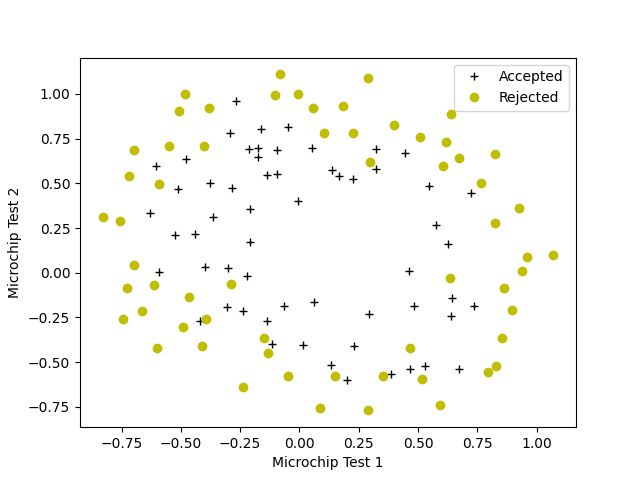

In [25]:
# Plot examples
plt.clf()
plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")

# Set the y-axis label
plt.ylabel('Microchip Test 2') 
# Set the x-axis label
plt.xlabel('Microchip Test 1') 
plt.legend(loc="upper right")
plt.show()

图 3 表明我们的数据集不能通过图中的一条直线分为正例和负例。因此，直接应用逻辑回归在这个数据集上表现不会很好，因为逻辑回归只能找到一个线性决策边界。

<a name="3.3"></a>
### 3.3 特征映射
一种更好地拟合数据的方法是从每个数据点创建更多的特征。在提供的函数`map_feature`中，我们将把特征映射为$x_1$和$x_2$的所有六次多项式项。

$$\mathrm{map\_feature}(x) = 
\left[\begin{array}{c}
x_1\\
x_2\\
x_1^2\\
x_1 x_2\\
x_2^2\\
x_1^3\\
\vdots\\
x_1 x_2^5\\
x_2^6\end{array}\right]$$

由于这种映射，我们的两个特征向量（两个质量评估测试的分数）已被转换为一个 27 维向量。

- 在这个高维特征向量上训练的逻辑回归分类器将具有更复杂的决策边界，并且在我们的二维图中绘制时将是非线性的。
- 我们在 utils.py 中为你提供了`map_feature`函数。

In [26]:
print("Original shape of data:", X_train.shape)

mapped_X =  map_feature(X_train[:, 0], X_train[:, 1])
print("Shape after feature mapping:", mapped_X.shape)

Original shape of data: (118, 2)
Shape after feature mapping: (118, 27)


让我们也打印出`X_train`和`mapped_X`的第一个元素以查看转换。

In [27]:
print("X_train[0]:", X_train[0])
print("mapped X_train[0]:", mapped_X[0])

X_train[0]: [0.051267 0.69956 ]
mapped X_train[0]: [5.12670000e-02 6.99560000e-01 2.62830529e-03 3.58643425e-02
 4.89384194e-01 1.34745327e-04 1.83865725e-03 2.50892595e-02
 3.42353606e-01 6.90798869e-06 9.42624411e-05 1.28625106e-03
 1.75514423e-02 2.39496889e-01 3.54151856e-07 4.83255257e-06
 6.59422333e-05 8.99809795e-04 1.22782870e-02 1.67542444e-01
 1.81563032e-08 2.47750473e-07 3.38066048e-06 4.61305487e-05
 6.29470940e-04 8.58939846e-03 1.17205992e-01]


虽然特征映射使我们能够构建一个更具表现力的分类器，但它也更容易过拟合。在练习的后续部分中，你将实现正则化逻辑回归以拟合数据，并亲眼看到正则化如何帮助解决过拟合问题。

<a name="3.4"></a>
### 3.4 正则化逻辑回归的成本函数

在这一部分，你将实现正则化逻辑回归的成本函数。

回想一下，对于正则化逻辑回归，成本函数的形式为：
$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

将此与没有正则化的成本函数进行比较（你在上面已经实现了这个函数），其形式为。

$$ J(\mathbf{w}.b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right]$$

差异在于正则化项，即 $$\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$ 
请注意，参数 $b$ 未被正则化。

<a name='ex-05'></a>
### 练习 5

请完成下面的`compute_cost_reg`函数以计算 $w$ 中每个元素的以下项：$$\frac{\lambda}{2m}  \sum_{j = 0}^{n - 1} w_j^2$$

入门代码随后将此项添加到未正则化的成本（你在上面的`compute_cost`中计算过）以计算正则化后的成本。

如果你遇到困难，可以查看下面单元格后的提示以帮助你实现。

In [28]:
# UNQ_C5
def compute_cost_reg(X, y, w, b, lambda_ = 1):
    """
    Computes the cost over all examples
    Args:
      X : (array_like Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value 
      w : (array_like Shape (n,)) Values of parameters of the model      
      b : (array_like Shape (n,)) Values of bias parameter of the model
      lambda_ : (scalar, float)    Controls amount of regularization
    Returns:
      total_cost: (scalar)         cost 
    """

    m, n = X.shape
    
    # Calls the compute_cost function that you implemented above
    cost_without_reg = compute_cost(X, y, w, b) 
    
    # You need to calculate this value
    reg_cost = 0.
    
    ### START CODE HERE ###
    for j in range(n):
        reg_cost_j = w[j]**2
        reg_cost = reg_cost + reg_cost_j

    ### END CODE HERE ### 
    
    # Add the regularization cost to get the total cost
    total_cost = cost_without_reg + (lambda_/(2 * m)) * reg_cost

    return total_cost

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
    
* Here's how you can structure the overall implementation for this function
    ```python 
       def compute_cost_reg(X, y, w, b, lambda_ = 1):
   
           m, n = X.shape
    
            # Calls the compute_cost function that you implemented above
            cost_without_reg = compute_cost(X, y, w, b) 
    
            # You need to calculate this value
            reg_cost = 0.
    
            ### START CODE HERE ###
            for j in range(n):
                reg_cost_j = # Your code here to calculate the cost from w[j]
                reg_cost = reg_cost + reg_cost_j

            ### END CODE HERE ### 
    
            # Add the regularization cost to get the total cost
            total_cost = cost_without_reg + (lambda_/(2 * m)) * reg_cost

        return total_cost
    ```
  
    If you're still stuck, you can check the hints presented below to figure out how to calculate `reg_cost_j` 
    
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate reg_cost_j</b></font></summary>
           &emsp; &emsp; You can use calculate reg_cost_j as <code>reg_cost_j = w[j]**2 </code> 
    </details>
        
    </details>

</details>

    

运行下面的单元格以检查你对`compute_cost_reg`函数的实现。

In [29]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5
cost = compute_cost_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print("Regularized cost :", cost)

# UNIT TEST    
compute_cost_reg_test(compute_cost_reg)


Regularized cost : 0.6618252552483948
All tests passed!


**预期输出**:
<table>
  <tr>
    <td> <b>Regularized cost : <b></td>
    <td> 0.6618252552483948 </td> 
  </tr>
</table>

<a name="3.5"></a>
### 3.5 正则化逻辑回归的梯度
在本节中，你将实现正则化逻辑回归的梯度。

正则化代价函数的梯度有两个组成部分。第一个，$\frac{\partial J(\mathbf{w},b)}{\partial b}$ 是一个标量，另一个是与参数 $\mathbf{w}$形状相同的向量，其中第$j$个元素定义如下：

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})$$

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \left( \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)} \right) + \frac{\lambda}{m} w_j  \quad\, \text{for $j=0...(n-1)$}$$
将其与无正则化的代价函数的梯度进行比较（你在上面已经实现了），其形式为
$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)}) \tag{2}
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)} \tag{3}
$$

如你所见，$\frac{\partial J(\mathbf{w},b)}{\partial b}$是相同的，区别在于$\frac{\partial J(\mathbf{w},b)}{\partial w}$中的以下项，即
$$\frac{\lambda}{m} w_j  \quad\, \text{for $j=0...(n-1)$}$$

<a name='ex-06'></a>
### 练习 6

请补全下面的`compute_gradient_reg`函数，以修改下面的代码来计算以下项

$$ \frac{\lambda}{m} w_j  \quad\, \text{for $j=0...(n-1)$} $$

起始代码会将这个项添加到上面的`compute_gradient`函数返回的$\frac{\partial J(\mathbf{w},b)}{\partial w}$中，以得到正则化代价函数的梯度。

如果你遇到困难，可以查看下面单元格后面给出的提示来帮助你实现。

In [30]:
# UNQ_C6
def compute_gradient_reg(X, y, w, b, lambda_ = 1): 
    """
    Computes the gradient for linear regression 
 
    Args:
      X : (ndarray Shape (m,n))   variable such as house size 
      y : (ndarray Shape (m,))    actual value 
      w : (ndarray Shape (n,))    values of parameters of the model      
      b : (scalar)                value of parameter of the model  
      lambda_ : (scalar,float)    regularization constant
    Returns
      dj_db: (scalar)             The gradient of the cost w.r.t. the parameter b. 
      dj_dw: (ndarray Shape (n,)) The gradient of the cost w.r.t. the parameters w. 

    """
    m, n = X.shape
    
    dj_db, dj_dw = compute_gradient(X, y, w, b)

    ### START CODE HERE ###     
    # Loop over the elements of w
    for j in range(n): 
        
        dj_dw_j_reg = (lambda_ / m) * w[j]
        
        # Add the regularization term  to the correspoding element of dj_dw
        dj_dw[j] = dj_dw[j] + dj_dw_j_reg
    
    ### END CODE HERE ###            
        
    return dj_db, dj_dw

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
    
* Here's how you can structure the overall implementation for this function
    ```python 
    def compute_gradient_reg(X, y, w, b, lambda_ = 1): 
        m, n = X.shape
    
        dj_db, dj_dw = compute_gradient(X, y, w, b)

        ### START CODE HERE ###     
        # Loop over the elements of w
        for j in range(n): 
            
            dj_dw_j_reg = # Your code here to calculate the regularization term for dj_dw[j]
            
            # Add the regularization term  to the correspoding element of dj_dw
            dj_dw[j] = dj_dw[j] + dj_dw_j_reg
        
        ### END CODE HERE ###         
        
        return dj_db, dj_dw
    ```
  
    If you're still stuck, you can check the hints presented below to figure out how to calculate `dj_dw_j_reg` 
    
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate dj_dw_j_reg</b></font></summary>
           &emsp; &emsp; You can use calculate dj_dw_j_reg as <code>dj_dw_j_reg = (lambda_ / m) * w[j] </code> 
    </details>
        
    </details>

</details>

    


运行下面的单元格以检查你对`compute_gradient_reg`函数的实现。

In [31]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1) 
initial_w  = np.random.rand(X_mapped.shape[1]) - 0.5 
initial_b = 0.5
 
lambda_ = 0.5
dj_db, dj_dw = compute_gradient_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print(f"dj_db: {dj_db}", )
print(f"First few elements of regularized dj_dw:\n {dj_dw[:4].tolist()}", )

# UNIT TESTS    
compute_gradient_reg_test(compute_gradient_reg)


dj_db: 0.07138288792343662
First few elements of regularized dj_dw:
 [-0.010386028450548701, 0.011409852883280124, 0.0536273463274574, 0.003140278267313462]
All tests passed!


**预期输出**:
<table>
  <tr>
    <td> <b>dj_db:</b>0.07138288792343656</td> </tr>
  <tr>
      <td> <b> First few elements of regularized dj_dw:</b> </td> </tr>
   <tr>
   <td> [[-0.010386028450548701], [0.01140985288328012], [0.0536273463274574], [0.003140278267313462]] </td> 
  </tr>
</table>

<a name="3.6"></a>
### 3.6 Learning parameters using gradient descent

Similar to the previous parts, you will use your gradient descent function implemented above to learn the optimal parameters $w$,$b$. 
- If you have completed the cost and gradient for regularized logistic regression correctly, you should be able to step through the next cell to learn the parameters $w$. 
- After training our parameters, we will use it to plot the decision boundary. 

**Note**

The code block below takes quite a while to run, especially with a non-vectorized version. You can reduce the `iterations` to test your implementation and iterate faster. If you hae time, run for 100,000 iterations to see better results.

### 3.6 使用梯度下降学习参数
与前面部分类似，你将使用上面实现的梯度下降函数来学习最优参数$w$、$b$。
- 如果你已经正确完成了正则化逻辑回归的代价函数和梯度计算，那么你应该能够执行下一个单元格来学习参数$w$。
- 在训练我们的参数之后，我们将使用它来绘制决策边界。

**注意**

下面的代码块运行需要相当长的时间，特别是在非向量化版本中。你可以减少`迭代次数`来测试你的实现并更快地迭代。如果你有时间，运行 100,000 次迭代以获得更好的结果。

In [32]:
# Initialize fitting parameters
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1])-0.5
initial_b = 1.

# Set regularization parameter lambda_ to 1 (you can try varying this)
lambda_ = 0.01;                                          
# Some gradient descent settings
iterations = 10000
alpha = 0.01

w,b, J_history,_ = gradient_descent(X_mapped, y_train, initial_w, initial_b, 
                                    compute_cost_reg, compute_gradient_reg, 
                                    alpha, iterations, lambda_)

Iteration    0: Cost     0.72   
Iteration 1000: Cost     0.59   
Iteration 2000: Cost     0.56   
Iteration 3000: Cost     0.53   
Iteration 4000: Cost     0.51   
Iteration 5000: Cost     0.50   
Iteration 6000: Cost     0.48   
Iteration 7000: Cost     0.47   
Iteration 8000: Cost     0.46   
Iteration 9000: Cost     0.45   
Iteration 9999: Cost     0.45   


<details>
<summary>
    <b>预期输出: Cost < 0.5  (Click for details)</b>
</summary>

```
# Using the following settings
#np.random.seed(1)
#initial_w = np.random.rand(X_mapped.shape[1])-0.5
#initial_b = 1.
#lambda_ = 0.01;                                          
#iterations = 10000
#alpha = 0.01
Iteration    0: Cost     0.72   
Iteration 1000: Cost     0.59   
Iteration 2000: Cost     0.56   
Iteration 3000: Cost     0.53   
Iteration 4000: Cost     0.51   
Iteration 5000: Cost     0.50   
Iteration 6000: Cost     0.48   
Iteration 7000: Cost     0.47   
Iteration 8000: Cost     0.46   
Iteration 9000: Cost     0.45   
Iteration 9999: Cost     0.45       
    
```

<a name="3.7"></a>
### 3.7 绘制决策边界

为了帮助你可视化这个分类器学习到的模型，我们将使用我们的`plot_decision_boundary`函数，该函数绘制分隔正例和负例的（非线性）决策边界。
- 在这个函数中，我们通过在均匀间隔的网格上计算分类器的预测来绘制非线性决策边界，然后绘制一个等高线图，其中预测从 y = 0 变为 y = 1。
- 在学习参数$w$、$b$之后，下一步是绘制一个类似于图 4 的决策边界。

<img src="images/figure 4.png"  width="450" height="450">

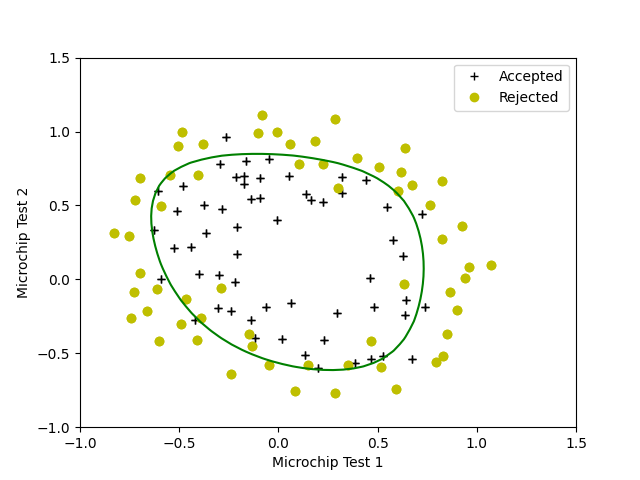

In [33]:
plot_decision_boundary(w, b, X_mapped, y_train)
plt.show()

<a name="3.8"></a>
### 3.8 评估正则化逻辑回归模型

你将使用上述实现的`predict`函数来计算正则化逻辑回归模型在训练集上的准确率。

In [34]:
#Compute accuracy on the training set
p = predict(X_mapped, w, b)

print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 82.203390


**预期输出**:
<table>
  <tr>
    <td> <b>Train Accuracy:</b>~ 80%</td> </tr>
</table>